<a href="https://colab.research.google.com/github/edemile/ML-Final-project/blob/main/DS4400_Project_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SVM Implementation
[Link to dataset](https://docs.google.com/spreadsheets/d/1K9R2xpxjPZYypVshY3fKUC5-VHWPgP0KxQivMES2zsQ/export?format=csv&gid=86751017)

In [14]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import roc_curve, confusion_matrix, ConfusionMatrixDisplay

In [15]:
# Import Google Drive to upload data
from google.colab import drive
drive.mount('/content/drive')

# Read in data from file path
file_id = '1K9R2xpxjPZYypVshY3fKUC5-VHWPgP0KxQivMES2zsQ'
file_path = f"https://docs.google.com/spreadsheets/d/{file_id}/export?format=csv&gid=86751017"

df = pd.read_csv(file_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
# Define feature columns
feature_cols = [
  'High blood pressure',
  'High cholesterol',
  'Taking medicine for high cholesterol',
  'Taking medicine to control high blood pressure'
]

# Separate features and target
X = df[feature_cols]
y = df['high_risk']

In [17]:
# Impute missing values using mean
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

In [18]:
# Split dataset into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(
  X_imputed, y,
  test_size=0.2,
  random_state=42,
  stratify=y
)

# Standardize features
scaler = StandardScaler()

# Fit scaler on training data and transform both sets
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Training set size: 599
Testing set size: 150


In [19]:
def compute_metrics(y_true, y_pred, y_probs, dataset_name):
  """ Computes and prints classification metrics.
  Args:
      y_true (numpy.ndarray): True labels
      y_pred (numpy.ndarray): Predicted class labels
      y_probs (numpy.ndarray): Predicted probabilities for positive class
      dataset_name (str): Name of dataset (e.g., "Training", "Testing")

  Returns:
      tuple: (accuracy, f1, auc)
  """

  # Compute standard classification metrics
  accuracy = accuracy_score(y_true, y_pred)
  precision = precision_score(y_true, y_pred)
  recall = recall_score(y_true, y_pred)
  f1 = f1_score(y_true, y_pred)
  auc = roc_auc_score(y_true, y_probs)

  # Print results
  print(f"\n{dataset_name} Metrics")
  print(f"Accuracy: {accuracy:.4f}")
  print(f"Precision: {precision:.4f}")
  print(f"Recall: {recall:.4f}")
  print(f"F1 Score: {f1:.4f}")
  print(f"ROC-AUC: {auc:.4f}")

  return accuracy, f1, auc

In [20]:
# Define hyperparameter grid for SVM
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

In [21]:
# Initialize SVM model with probability enabled for ROC-AUC
svm = SVC(probability=True, random_state=42)

# Use grid search with cross-validation to find best parameters
grid_search = GridSearchCV(svm, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Print best parameters
print(f"\nBest parameters: {grid_search.best_params_}")

# Train final model using best parameters
best_model = grid_search.best_estimator_


Best parameters: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}


In [22]:
# Generate predictions for training and testing sets
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

# Get predicted probabilities for ROC-AUC
y_train_probs = best_model.predict_proba(X_train)[:, 1]
y_test_probs = best_model.predict_proba(X_test)[:, 1]

# Compute metrics for training set
compute_metrics(y_train, y_train_pred, y_train_probs, "Training")

# Compute metrics for testing set
_, _, test_auc = compute_metrics(y_test, y_test_pred, y_test_probs, "Testing")


Training Metrics
Accuracy: 0.7947
Precision: 0.7867
Recall: 0.8606
F1 Score: 0.8220
ROC-AUC: 0.8483

Testing Metrics
Accuracy: 0.7733
Precision: 0.7526
Recall: 0.8795
F1 Score: 0.8111
ROC-AUC: 0.8311


In [23]:
# Create pipeline
pipeline = Pipeline([
  ("scaler", StandardScaler()),
  ("svm", best_model)
])

# Perform cross-validation on full dataset using best model
cv_scores = cross_val_score(pipeline, X_imputed, y, cv=5, scoring='f1')

print(f"\n5-Fold Cross-Validation F1 Scores: {cv_scores}")
print(f"Mean CV F1: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")


5-Fold Cross-Validation F1 Scores: [0.8372093  0.87356322 0.78823529 0.80473373 0.7672956 ]
Mean CV F1: 0.8142 (+/- 0.0375)


In [24]:
def plot_roc(y_true, y_probs, auc_score):
    """ Plots ROC curve.
    Args:
        y_true (numpy.ndarray): True labels
        y_probs (numpy.ndarray): Predicted probabilities
        auc_score (float): AUC value

    Returns:
        None
    """

    # Compute false positive and true positive rates
    fpr, tpr, _ = roc_curve(y_true, y_probs)

    # Plot ROC curve
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, lw=2, label=f'ROC Curve (AUC = {auc_score:.2f})')
    plt.plot([0, 1], [0, 1], linestyle='--', label='Random Classifier')

    # Labels and title
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('SVM - ROC Curve')
    plt.legend(loc='lower right')

    # Show plot
    plt.tight_layout()
    plt.show()

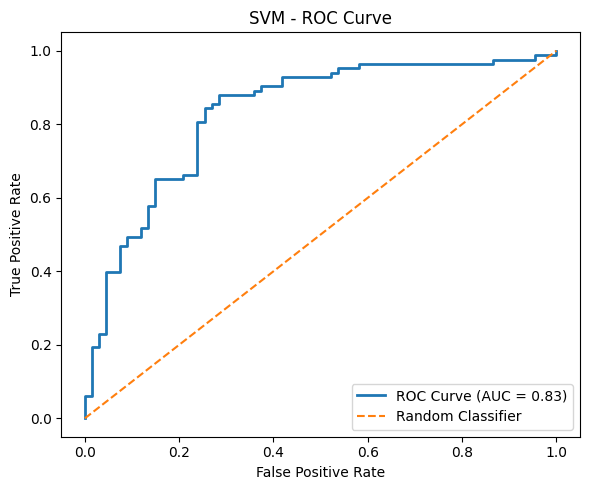

In [25]:
# Plot ROC curve
plot_roc(y_test, y_test_probs, test_auc)

In [26]:
def plot_confusion(y_true, y_pred):
  """ Plots confusion matrix.
  Args:
      y_true (numpy.ndarray): True labels
      y_pred (numpy.ndarray): Predicted labels

  Returns:
      None
  """

  # Compute confusion matrix
  cm = confusion_matrix(y_true, y_pred)

  # Display confusion matrix
  disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low Risk', 'High Risk'])

  fig, ax = plt.subplots(figsize=(5, 4))
  disp.plot(ax=ax, colorbar=False, cmap='Blues')
  plt.title('SVM - Confusion Matrix')
  plt.tight_layout()
  plt.show()

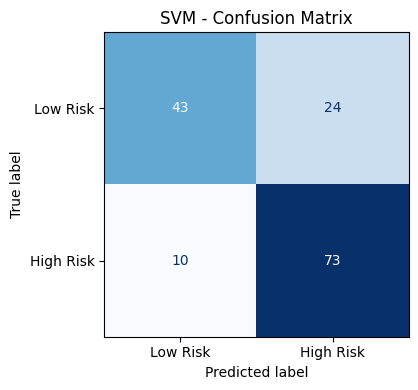

In [27]:
# Plot confusion matrix
plot_confusion(y_test, y_test_pred)